Overview: This jupyter notebook studies whether the conclusion of frequency spliting applies directly to original input unwrapped texture. 

Short answer: yes. 

Applying frequency decomposition to unwrapped texture gives the same conclusion as applying frequency decomposition to difference between unwrapped texture and texture average.

In [1]:
from library import *

camera config file for 6795937 exists, loading...
[['E001_Neutral_Eyes_Open' '000102']
 ['E002_Swallow' '000181']
 ['E017_Jaw_Open_Mouth_Corners_Down_Nose_Wrinkled' '006196']
 ['E018_Raise_Cheeks' '006481']
 ['E019_Frown' '006778']
 ['E020_Lower_Eyebrows' '007066']
 ['E021_Pressed_Lips_Brows_Down' '007407']
 ['E022_Raise_Inner_Eyebrows' '007802']
 ['E023_Hide_Lips_Look_Up' '008121']
 ['E024_Kiss_Lips_Look_Down' '008443']
 ['E025_Shh' '008800']
 ['E026_Oooo' '009119']
 ['E027_Scrunch_Face_Squeeze_Eyes' '009461']
 ['E003_Neutral_Eyes_Closed' '000777']
 ['E028_Scream_Eyebrows_Up' '009813']
 ['E029_Show_All_Teeth' '010225']
 ['E030_Open_Mouth_Wide_Tongue_Up_And_Back' '011147']
 ['E031_Jaw_Open_Lips_Together' '011487']
 ['E032_Jaw_Open_Pull_Lips_In' '011855']
 ['E033_Jaw_Clench' '012196']
 ['E034_Jaw_Open_Lips_Pushed_Out' '012581']
 ['E004_Relaxed_Mouth_Open' '001081']
 ['E035_Lips_Together_Pushed_Forward' '012955']
 ['E036_Stick_Lower_Lip_Out' '013244']
 ['E037_Bite_Lower_Lip' '013586']
 [

# Step 1: Drop High Frequency Components
1. Let's try break down input image into various frequency components. 
2. Drop **high** frequency components by masking it all zeros. 
3. Reconstruct the overall image with modified frequency components.
4. Calculate the difference between the reconstructed image with high frequency components dropped and original image.

In [2]:
test_img_path = "/work/dataset/m--20180227--0000--6795937--GHS/unwrapped_uv_1024/E001_Neutral_Eyes_Open/average/000102.png"
test_image_tensor = load_image(test_img_path)
overall_img_drop_high_freq_list = []
block_size = 4 
total_block_num = block_size * block_size
bs, ch, h, w = test_image_tensor.shape
base_freq_cutoff_list = [i for i in range(1, total_block_num+1, 1)]
for base_freq_cutoff in base_freq_cutoff_list:
    test_inverse_transformed_img = test_img_dct_transform_drop_high_freq_reorder(test_image_tensor, bs, ch, h, w, base_freq_cutoff)
    transforms.functional.to_pil_image(test_inverse_transformed_img.squeeze(0)).save(f'reconstruct_dct_idct_image_drop_high_freq_{base_freq_cutoff}.png')
    overall_img_drop_high_freq_list.append(test_inverse_transformed_img)

zero out 1~15-th frequency components, whether reconstructed image is close to original image? False
zero out 2~15-th frequency components, whether reconstructed image is close to original image? False
zero out 3~15-th frequency components, whether reconstructed image is close to original image? False
zero out 4~15-th frequency components, whether reconstructed image is close to original image? False
zero out 5~15-th frequency components, whether reconstructed image is close to original image? False
zero out 6~15-th frequency components, whether reconstructed image is close to original image? False
zero out 7~15-th frequency components, whether reconstructed image is close to original image? False
zero out 8~15-th frequency components, whether reconstructed image is close to original image? False
zero out 9~15-th frequency components, whether reconstructed image is close to original image? False
zero out 10~15-th frequency components, whether reconstructed image is close to original im

Conclusion 1: When dropping image, there is a difference. When no components are zero out, it looks similar as original input.

In [3]:
# Calculate l2 norm between original and each different frequency components
test_img_path = "/work/dataset/m--20180227--0000--6795937--GHS/unwrapped_uv_1024/E001_Neutral_Eyes_Open/average/000102.png"
test_image_tensor = load_image(test_img_path)
l2_norm_drop_freq_difference_list = []
for img in overall_img_drop_high_freq_list:
    l2_norm_drop_freq_difference_list.append(torch.norm(torch.subtract(img, test_image_tensor)))

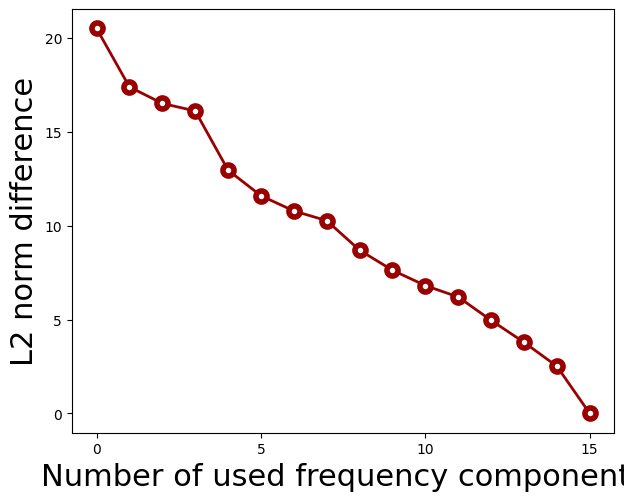

In [4]:
import matplotlib.pyplot as plt

prior_sr =  1/66
fig = plt.figure(figsize=[7,5.5])
ax = plt.subplot(111)
x = [i for i in range(len(l2_norm_drop_freq_difference_list))]
# l2_norm_noise = l2_norm_noise[::-1]
# prior_successful_rate_list = prior_successful_rate_list[::-1]
plt.plot(x, l2_norm_drop_freq_difference_list, color="#990000", marker=".", markerfacecolor="#ffffff", markersize=16, linewidth=2, markeredgewidth=4)

SMALL_SIZE = 18
MEDIUM_SIZE = 20
BIGGER_SIZE = 22

plt.ylabel("L2 norm difference", fontsize=BIGGER_SIZE)
plt.xlabel("Number of used frequency components", fontsize=BIGGER_SIZE)
# plt.xticks([i for i in range(int(max(tflop_list)+1))], [str(i) for i in range(int(max(tflop_list)+1))], fontsize=MEDIUM_SIZE)
# plt.title("Scores by Teams in 4 Rounds")

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize

plt.savefig('l2norm_under_various_freq_comp.pdf', bbox_inches="tight", transparent=True) 

plt.show()

# Step 2: Drop High Frequency Components, Use low frequency as replacement.
1. Let's try break down input image into various frequency components. 
2. Drop **high** frequency components by duplicating the highest available component to all higher frequency components.
3. Reconstruct the overall image with modified frequency components.
4. Calculate the difference between the reconstructed image with high frequency components dropped and original image.

In [5]:
test_img_path = "/work/dataset/m--20180227--0000--6795937--GHS/unwrapped_uv_1024/E001_Neutral_Eyes_Open/average/000102.png"
test_image_tensor = load_image(test_img_path)
overall_img_duplicate_freq_list = []
block_size = 4 
total_block_num = block_size * block_size
bs, ch, h, w = test_image_tensor.shape
base_freq_cutoff_list = [i for i in range(1,total_block_num+1,1)]
for base_freq_cutoff in base_freq_cutoff_list:
    test_inverse_transformed_img = test_img_dct_transform_duplicate_freq_reorder(test_image_tensor, bs, ch, h, w, base_freq_cutoff)
    transforms.functional.to_pil_image(test_inverse_transformed_img.squeeze(0)).save(f'reconstruct_dct_idct_image_duplicate_freq_{base_freq_cutoff}.png')
    overall_img_duplicate_freq_list.append(test_inverse_transformed_img)

duplicate 1-th frequency component to all 0-th to 15-th frequency components, whether reconstructed image is close to original image? False
duplicate 2-th frequency component to all 1-th to 15-th frequency components, whether reconstructed image is close to original image? False
duplicate 3-th frequency component to all 2-th to 15-th frequency components, whether reconstructed image is close to original image? False
duplicate 4-th frequency component to all 3-th to 15-th frequency components, whether reconstructed image is close to original image? False
duplicate 5-th frequency component to all 4-th to 15-th frequency components, whether reconstructed image is close to original image? False
duplicate 6-th frequency component to all 5-th to 15-th frequency components, whether reconstructed image is close to original image? False
duplicate 7-th frequency component to all 6-th to 15-th frequency components, whether reconstructed image is close to original image? False
duplicate 8-th frequ

In [6]:
# Calculate l2 norm between original and each different frequency components
test_img_path = "/work/dataset/m--20180227--0000--6795937--GHS/unwrapped_uv_1024/E001_Neutral_Eyes_Open/average/000102.png"
test_image_tensor = load_image(test_img_path)
l2_norm_duplicate_freq_difference_list = []
for img in overall_img_duplicate_freq_list:
    l2_norm_duplicate_freq_difference_list.append(torch.norm(torch.subtract(img, test_image_tensor)))

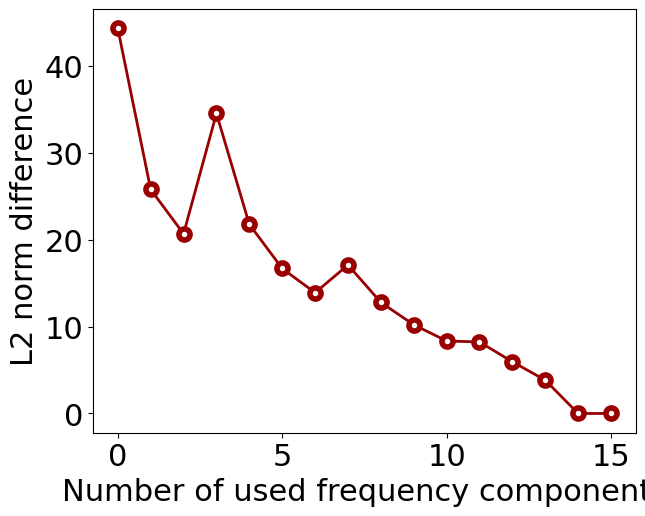

In [7]:
import matplotlib.pyplot as plt

prior_sr =  1/66
fig = plt.figure(figsize=[7,5.5])
ax = plt.subplot(111)
x = [i for i in range(len(l2_norm_duplicate_freq_difference_list))]
# l2_norm_noise = l2_norm_noise[::-1]
# prior_successful_rate_list = prior_successful_rate_list[::-1]
plt.plot(x, l2_norm_duplicate_freq_difference_list, color="#990000", marker=".", markerfacecolor="#ffffff", markersize=16, linewidth=2, markeredgewidth=4)

SMALL_SIZE = 18
MEDIUM_SIZE = 20
BIGGER_SIZE = 22

plt.ylabel("L2 norm difference", fontsize=BIGGER_SIZE)
plt.xlabel("Number of used frequency components", fontsize=BIGGER_SIZE)
# plt.xticks([i for i in range(int(max(tflop_list)+1))], [str(i) for i in range(int(max(tflop_list)+1))], fontsize=MEDIUM_SIZE)
# plt.title("Scores by Teams in 4 Rounds")

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize

plt.savefig('raw_img_l2norm_duplicated_low_higher_freq_comp.pdf', bbox_inches="tight", transparent=True) 

plt.show()

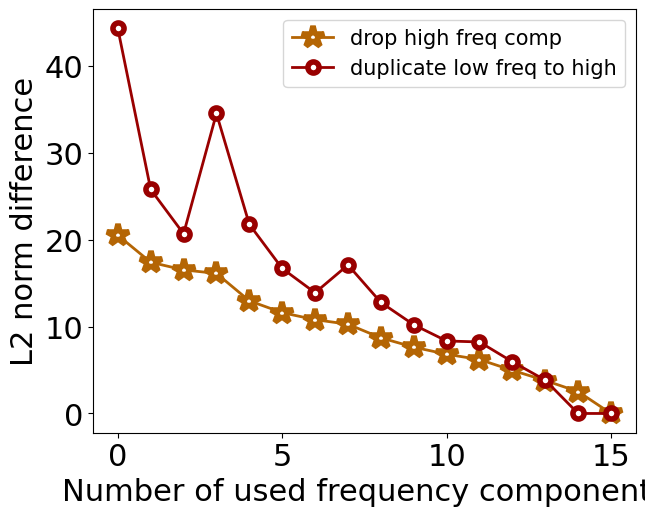

In [8]:
import matplotlib.pyplot as plt

prior_sr =  1/66
fig = plt.figure(figsize=[7,5.5])
ax = plt.subplot(111)
x = [i for i in range(len(l2_norm_duplicate_freq_difference_list))]
# l2_norm_noise = l2_norm_noise[::-1]
# prior_successful_rate_list = prior_successful_rate_list[::-1]
plt_handler = []
plt_handler.append(plt.plot(x, l2_norm_drop_freq_difference_list, marker="*", markerfacecolor="#ffffff", color="#B46504", markersize=16, linewidth=2, markeredgewidth=4)[0])
plt_handler.append(plt.plot(x, l2_norm_duplicate_freq_difference_list, color="#990000", marker=".", markerfacecolor="#ffffff", markersize=16, linewidth=2, markeredgewidth=4)[0])

SMALL_SIZE = 18
MEDIUM_SIZE = 20
BIGGER_SIZE = 22

plt.ylabel("L2 norm difference", fontsize=BIGGER_SIZE)
plt.xlabel("Number of used frequency components", fontsize=BIGGER_SIZE)
# plt.xticks([i for i in range(int(max(tflop_list)+1))], [str(i) for i in range(int(max(tflop_list)+1))], fontsize=MEDIUM_SIZE)
# plt.title("Scores by Teams in 4 Rounds")

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize
plt.legend(plt_handler, [r"drop high freq comp", r"duplicate low freq to high"], loc='best', ncol=1, fontsize=15)

plt.savefig('raw_img_l2norm_zero_out_lower_duplicate_comparison.pdf', bbox_inches="tight", transparent=True) 

plt.show()

# Step 3: Zero out Low Frequency Components.
1. Let's try break down input image into various frequency components. 
2. Drop **low** frequency components by zeroing out them
3. Reconstruct the overall image with modified frequency components.
4. Calculate the difference between the reconstructed image with high frequency components dropped and original image.

In [9]:
test_img_path = "/work/dataset/m--20180227--0000--6795937--GHS/unwrapped_uv_1024/E001_Neutral_Eyes_Open/average/000102.png"
test_image_tensor = load_image(test_img_path)
overall_img_drop_low_freq_list = []
block_size = 4 
total_block_num = block_size * block_size
bs, ch, h, w = test_image_tensor.shape
base_freq_cutoff_list = [i for i in range(1, total_block_num+1, 1)]
for base_freq_cutoff in base_freq_cutoff_list:
    test_inverse_transformed_img = test_img_dct_transform_drop_low_freq_reorder(test_image_tensor, bs, ch, h, w, base_freq_cutoff)
    transforms.functional.to_pil_image(test_inverse_transformed_img.squeeze(0)).save(f'reconstruct_dct_idct_image_drop_low_freq_{base_freq_cutoff}.png')
    overall_img_drop_low_freq_list.append(test_inverse_transformed_img)

zero out 1-th to 15-th frequency components, whether reconstructed image is close to original image? False
zero out 2-th to 15-th frequency components, whether reconstructed image is close to original image? False
zero out 3-th to 15-th frequency components, whether reconstructed image is close to original image? False
zero out 4-th to 15-th frequency components, whether reconstructed image is close to original image? False
zero out 5-th to 15-th frequency components, whether reconstructed image is close to original image? False
zero out 6-th to 15-th frequency components, whether reconstructed image is close to original image? False
zero out 7-th to 15-th frequency components, whether reconstructed image is close to original image? False
zero out 8-th to 15-th frequency components, whether reconstructed image is close to original image? False
zero out 9-th to 15-th frequency components, whether reconstructed image is close to original image? False
zero out 10-th to 15-th frequency com

In [10]:
# Calculate l2 norm between original and each different frequency components
test_img_path = "/work/dataset/m--20180227--0000--6795937--GHS/unwrapped_uv_1024/E001_Neutral_Eyes_Open/average/000102.png"
test_image_tensor = load_image(test_img_path)
l2_norm_drop_freq_difference_list = []
for img in overall_img_drop_low_freq_list:
    l2_norm_drop_freq_difference_list.append(torch.norm(torch.subtract(img, test_image_tensor)))

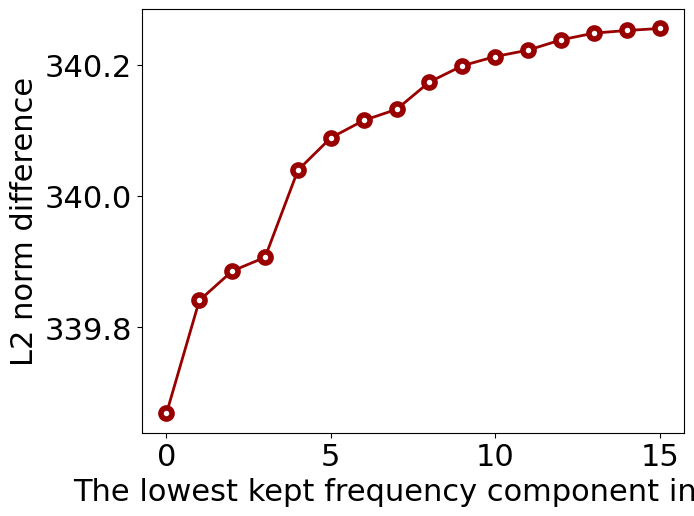

In [11]:
import matplotlib.pyplot as plt

prior_sr =  1/66
fig = plt.figure(figsize=[7,5.5])
ax = plt.subplot(111)
x = [i for i in range(len(l2_norm_drop_freq_difference_list))]
# l2_norm_noise = l2_norm_noise[::-1]
# prior_successful_rate_list = prior_successful_rate_list[::-1]
plt.plot(x, l2_norm_drop_freq_difference_list, color="#990000", marker=".", markerfacecolor="#ffffff", markersize=16, linewidth=2, markeredgewidth=4)

SMALL_SIZE = 18
MEDIUM_SIZE = 20
BIGGER_SIZE = 22

plt.ylabel("L2 norm difference", fontsize=BIGGER_SIZE)
plt.xlabel("The lowest kept frequency component index", fontsize=BIGGER_SIZE)
# plt.xticks([i for i in range(int(max(tflop_list)+1))], [str(i) for i in range(int(max(tflop_list)+1))], fontsize=MEDIUM_SIZE)
# plt.title("Scores by Teams in 4 Rounds")

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)    # legend fontsize

plt.savefig('raw_img_l2norm_zero_out_lower.pdf', bbox_inches="tight", transparent=True) 

plt.show()